<a href="https://colab.research.google.com/github/ACobo98/Turbulence-Software/blob/main/Exact_Solution_of_the_Nonlinear_Pendulum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Espacio de Fases

Librerias

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Función para plotear el espacio de fases con un parámetro k definido


In [5]:
def plot_pendulum_phase_curve(k=0.6, num_points=1000):
    #Rango de z entre -1 y 1
    z = np.linspace(-1, 1, num_points)

    #(dz/dτ)^2 = (1 - z^2)(1 - k z^2)
    inside = (1 - z**2) * (1 - k * z**2)
    inside = np.maximum(inside, 0.0)

    #Dos ramas: positiva y negativa
    dzdt_pos = np.sqrt(inside)
    dzdt_neg = -dzdt_pos

    #Grafica
    plt.figure(figsize=(7, 5))
    plt.plot(z, dzdt_neg, label=r"$-\sqrt{(1-z^2)(1-kz^2)}$")
    orange = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]
    plt.plot(z, dzdt_pos, label=r"$+\sqrt{(1-z^2)(1-kz^2)}$")
    plt.scatter([1.0], [0.0], s=40, marker='o',color=orange,
                label="Turning point (1, 0)")

    plt.title(r"Phase curve: $(dz/d\tau)^2 = (1-z^2)(1-k z^2)$  with  $k={}$".format(k))
    plt.xlabel(r"$z$")
    plt.ylabel(r"$dz/d\tau$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Ejecución de la función

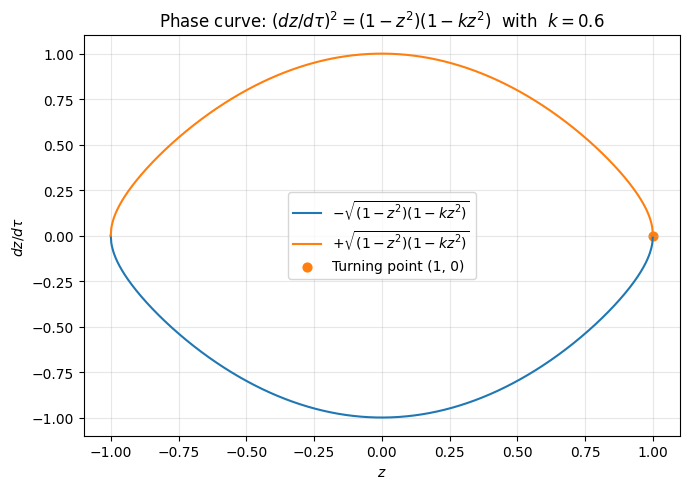

In [6]:
plot_pendulum_phase_curve(k=0.6)

# Grafica Evolución del Ángulo en Función del Tiempo

Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipk, ellipj

Parámetros

In [2]:
g = 9.81
l = 1.0
theta0 = np.radians(60)
omega0 = np.sqrt(g/l)
k = np.sin(theta0/2)**2
Kk = ellipk(k)
T = 4*Kk/omega0

t = np.linspace(0, 2*T, 1000)


u = Kk - omega0*t
sn, cn, dn, ph = ellipj(u, k)
y = np.sin(theta0/2) * sn
theta_t = 2*np.arcsin(y)

Gráfica

/tmp/ipython-input-2528380497.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


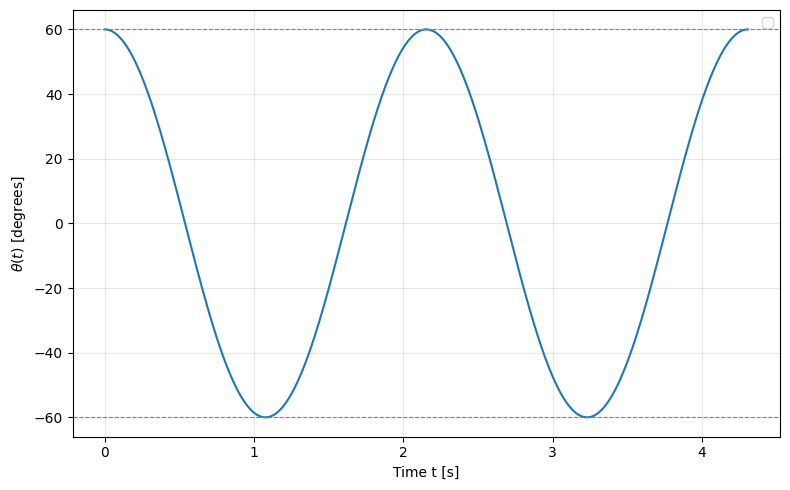

In [3]:
plt.figure(figsize=(8,5))
plt.plot(t, np.degrees(theta_t))
plt.axhline(np.degrees(theta0), color='gray', ls='--', lw=0.8)
plt.axhline(-np.degrees(theta0), color='gray', ls='--', lw=0.8)
plt.xlabel("Time t [s]")
plt.ylabel(r"$\theta(t)$ [degrees]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()